In [1]:
!pip install pandas


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!pip install Xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.1/101.7 MB 37.1 MB/s eta 0:00:03
   ----- ---------------------------------- 13.9/101.7 MB 46.4 MB/s eta 0:00:02
   --------- ------------------------------ 25.2/101.7 MB 49.1 MB/s eta 0:00:02
   -------------- ------------------------- 36.2/101.7 MB 50.8 MB/s eta 0:00:02
   --------------- ------------------------ 40.4/101.7 MB 43.4 MB/s eta 0:00:02
   ------------------- -------------------- 48.5/101.7 MB 43.1 MB/s eta 0:00:02
   ----------------------- ---------------- 59.2/101.7 MB 44.2 MB/s eta 0:00:01
   ------------------------- -------------- 64.0/101.7 MB 41.5 MB/s eta 0:00:01
   ----------------------------- ---------- 75.5/101.7 MB 43.2 MB/s eta 0:00:01
   ---------------------------------- ----- 87.3/101.7 MB 44.8 MB/s eta 0:00:01
   -------------------------------------- - 99.1/101.7 MB 46.1 MB/s eta 0:00:01
   --------------------------------------  101.4/1


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

Load the Data

In [10]:
train = pd.read_csv(r"C:\Users\sg961\Downloads\archive\rossmann-store-sales\train.csv", parse_dates=["Date"], low_memory=False)
store = pd.read_csv(r"C:\Users\sg961\Downloads\archive\rossmann-store-sales\store.csv")

print("Train shape:", train.shape)
print("Store shape:", store.shape)
train.head()

Train shape: (1017209, 9)
Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


Merge & Inspect

In [11]:
df = train.merge(store, on="Store", how="left")
print(df.shape)
print(df.info())
print(df.isnull().sum())
df.head()

(1017209, 18)
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


Data Cleaning

In [12]:
# Keep only days the store was open and had sales
df = df[(df["Open"] == 1) & (df["Sales"] > 0)]

# Fill missing competition/promo info
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(df["CompetitionDistance"].median())
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna("None")

df = df.sort_values(["Store", "Date"]).reset_index(drop=True)
print("After cleaning:", df.shape)

After cleaning: (844338, 18)


Feature Engineering

In [13]:
# Date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# Encode categorical columns
df["StateHoliday"] = df["StateHoliday"].astype(str).map({"0": 0, "a": 1, "b": 2, "c": 3}).fillna(0)
df["StoreType"] = df["StoreType"].map({"a": 0, "b": 1, "c": 2, "d": 3})
df["Assortment"] = df["Assortment"].map({"a": 0, "b": 1, "c": 2})

print(df[["Date", "Sales", "Store", "DayOfWeek", "Promo", "StoreType"]].head())

        Date  Sales  Store  DayOfWeek  Promo  StoreType
0 2013-01-02   5530      1          2      0          2
1 2013-01-03   4327      1          3      0          2
2 2013-01-04   4486      1          4      0          2
3 2013-01-05   4997      1          5      0          2
4 2013-01-07   7176      1          0      1          2


Visualization

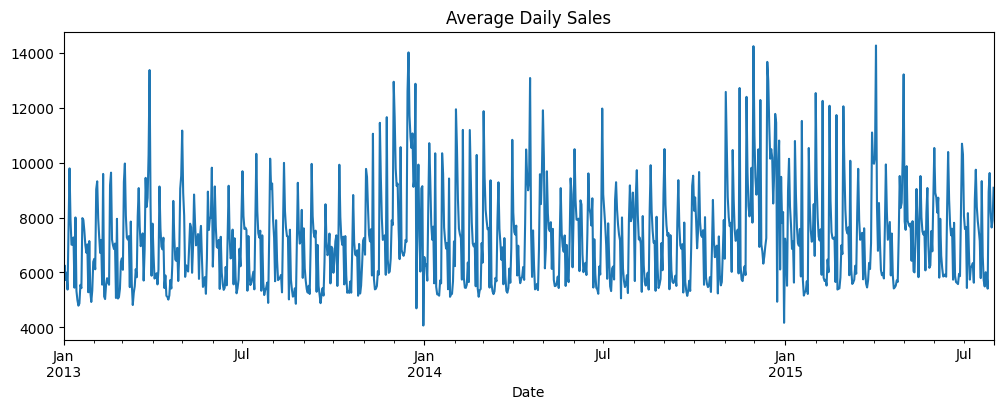

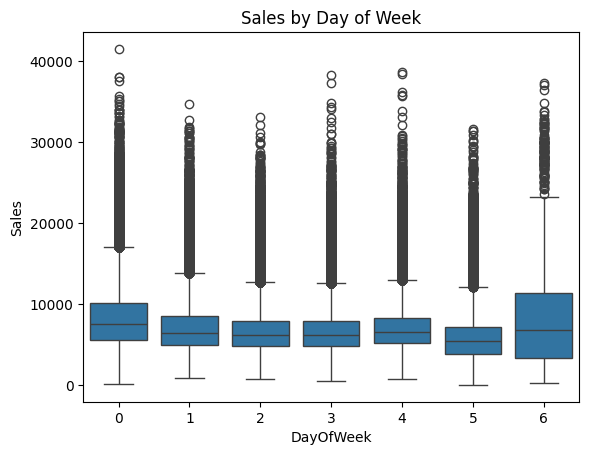

In [14]:
df.groupby("Date")["Sales"].mean().plot(figsize=(12, 4), title="Average Daily Sales")
plt.show()

sns.boxplot(x="DayOfWeek", y="Sales", data=df)
plt.title("Sales by Day of Week"); plt.show()

Feature Engineering

In [21]:
df = df.sort_values(["Store", "Date"]).reset_index(drop=True)

# Lag features (past sales per store)
df["Sales_lag_7"]  = df.groupby("Store")["Sales"].shift(7)
df["Sales_lag_14"] = df.groupby("Store")["Sales"].shift(14)
df["Sales_lag_30"] = df.groupby("Store")["Sales"].shift(30)

# Rolling averages (per store)
df["Sales_roll_7"]  = df.groupby("Store")["Sales"].shift(1).rolling(7).mean().reset_index(0, drop=True)
df["Sales_roll_30"] = df.groupby("Store")["Sales"].shift(1).rolling(30).mean().reset_index(0, drop=True)

# Drop rows that don't have enough history
df = df.dropna().reset_index(drop=True)

Feature Engineering

In [29]:
# Sales trends per store
df["Sales_roll_7_std"] = df.groupby("Store")["Sales"].shift(1).rolling(7).std().reset_index(0, drop=True)
df["Sales_roll_30_max"] = df.groupby("Store")["Sales"].shift(1).rolling(30).max().reset_index(0, drop=True)

# Days since competition opened
df["CompetitionOpen"] = 12 * (df["Year"] - df["CompetitionOpenSinceYear"]) + \
                        (df["Month"] - df["CompetitionOpenSinceMonth"])
df["CompetitionOpen"] = df["CompetitionOpen"].apply(lambda x: x if x > 0 else 0)

# Clean up any new NaNs from rolling
df = df.dropna().reset_index(drop=True)

Train Test Split

In [31]:
features = ["Store", "DayOfWeek", "Promo", "StateHoliday", "SchoolHoliday",
            "StoreType", "Assortment", "CompetitionDistance",
            "Year", "Month", "Day", "WeekOfYear", "IsWeekend",
            "Sales_lag_7", "Sales_lag_14", "Sales_lag_30",
            "Sales_roll_7", "Sales_roll_30",
            "Sales_roll_7_std", "Sales_roll_30_max", "CompetitionOpen"]
X = df[features]
y = df["Sales"]

# Use last 6 weeks as test set 
cutoff = df["Date"].max() - pd.Timedelta(weeks=6)
train_mask = df["Date"] <= cutoff

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (703706, 21) Test: (40282, 21)


 Linear Regression

In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Linear Regression")
print(f"  MAE : {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.2f}")
print(f"  R²  : {r2_score(y_test, lr_pred):.3f}")

Linear Regression
  MAE : 957.93
  RMSE: 1329.89
  R²  : 0.810


XGBoost

In [32]:
import numpy as np

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

xgb = XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb.fit(X_train, y_train_log,
        eval_set=[(X_test, y_test_log)],
        verbose=False)

xgb_pred = np.expm1(xgb.predict(X_test))   # back to original scale

print(f"MAE : {mean_absolute_error(y_test, xgb_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.2f}")
print(f"R²  : {r2_score(y_test, xgb_pred):.3f}")

MAE : 593.86
RMSE: 874.01
R²  : 0.918


Predicted Visualization

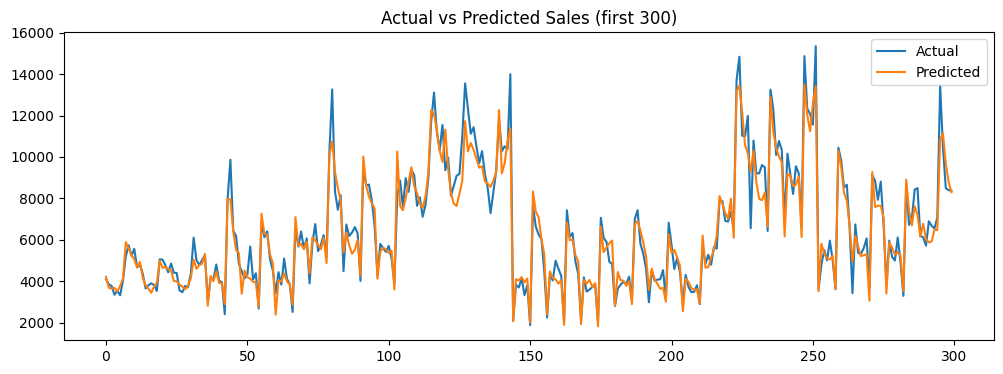

In [33]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(xgb_pred[:300], label="Predicted")
plt.legend(); plt.title("Actual vs Predicted Sales (first 300)"); plt.show()

Feature Importance

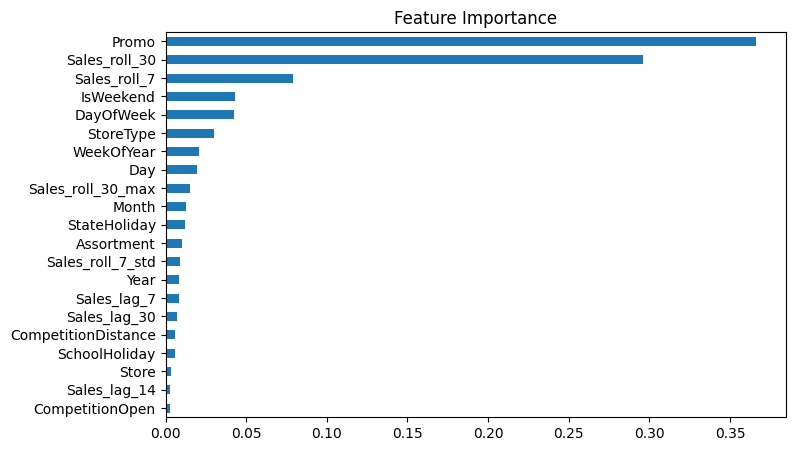

In [34]:
imp = pd.Series(xgb.feature_importances_, index=features).sort_values()
imp.plot(kind="barh", figsize=(8, 5), title="Feature Importance")
plt.show()

In [35]:
import joblib
joblib.dump(xgb, "rossmann_xgb.pkl")
print("Model saved as rossmann_xgb.pkl")

# Reload later with:
# model = joblib.load("rossmann_xgb.pkl")

Model saved as rossmann_xgb.pkl


In [36]:
# 1. Save predictions (actual vs predicted)
results = pd.DataFrame({
    "Date": df.loc[~train_mask, "Date"].values,
    "Store": df.loc[~train_mask, "Store"].values,
    "Actual_Sales": y_test.values,
    "Predicted_Sales": xgb_pred.round(2),
    "Error": (y_test.values - xgb_pred).round(2)
})
results.to_csv("sales_predictions.csv", index=False)
print("✅ Predictions saved → sales_predictions.csv")

# 2. Save metrics summary
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [
        round(mean_absolute_error(y_test, xgb_pred), 2),
        round(np.sqrt(mean_squared_error(y_test, xgb_pred)), 2),
        round(r2_score(y_test, xgb_pred), 3)
    ]
})
metrics.to_csv("model_metrics.csv", index=False)
print("✅ Metrics saved → model_metrics.csv")

# 3. Save feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False)
importance.to_csv("feature_importance.csv", index=False)
print("✅ Feature importance saved → feature_importance.csv")

✅ Predictions saved → sales_predictions.csv
✅ Metrics saved → model_metrics.csv
✅ Feature importance saved → feature_importance.csv
